In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv("G:\Pw skills\Assignment 45 ()\loan_approval - loan_approval.csv")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\NCS\AppData\Local\Temp\ipykernel_7204\2243768912.py:1: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("G:\Pw skills\Assignment 45 ()\loan_approval - loan_approval.csv")


FIRST 5 ROWS
   city  income  credit_score  loan_amount  years_employed  points  \
0   326  113810           389        39698              27      50   
1   989   44592           729        15446              28      55   
2   763   33278           584        11189              13      45   
3  1793  127196           344        48823              29      50   
4   841   66048           496        47174               4      25   

   loan_approved  
0              0  
1              0  
2              0  
3              0  
4              0  

SHAPE
(2000, 7)

DATA TYPES
city              int64
income            int64
credit_score      int64
loan_amount       int64
years_employed    int64
points            int64
loan_approved     int64
dtype: object

MISSING VALUES
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


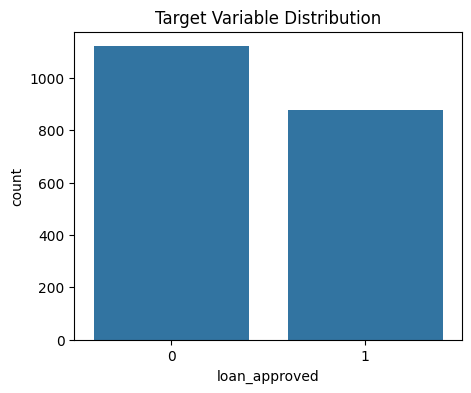


Accuracy: 1.0

Confusion Matrix
[[217   0]
 [  0 183]]


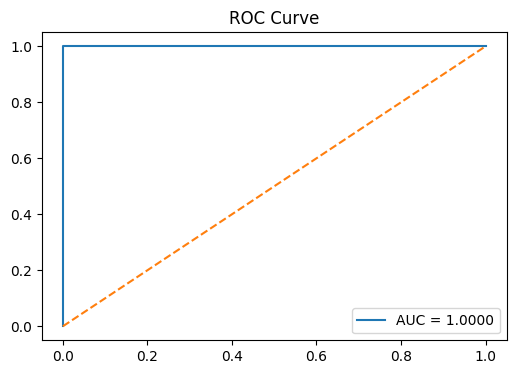


AUC Score: 1.0


In [11]:
print("FIRST 5 ROWS")
print(df.head())

print("\nSHAPE")
print(df.shape)

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

# Missing value treatment
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# EDA
target_col = 'loan_approved'

plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=df)
plt.title("Target Variable Distribution")
plt.show()

# Drop name column if present
if 'name' in df.columns:
    df.drop('name', axis=1, inplace=True)

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Convert boolean target
if df[target_col].dtype == 'bool':
    df[target_col] = df[target_col].astype(int)

# Features and target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix")
print(cm)

# ROC-AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

print("\nAUC Score:", auc)
